# Домашнее задание 6


Форк тут: https://github.com/Anya497/Decision-Transformer-with-Memory-for-POMDPs


## Задание 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def show_image(path):
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### Запуск с дефолтными настройками

#### DT

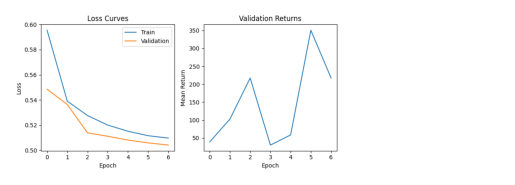

In [24]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_None_training.png")

Average reward over 5 episodes: 309.00

#### DT+GRU

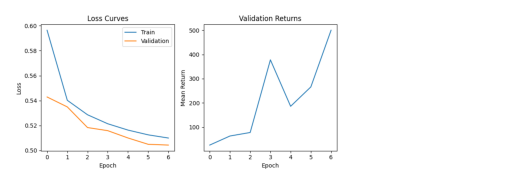

In [25]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_gru_training.png")

Average reward over 5 episodes: 362.00

#### DT+LSTM

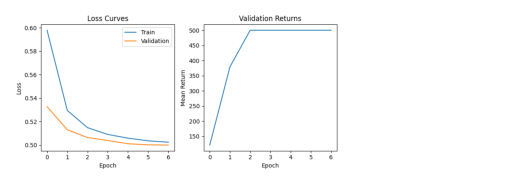

In [7]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_lstm_training.png")

Average reward over 5 episodes: 500.00

#### Анализ графиков

* Быстрее всего обучился LSTM (за 2 эпохи он уже получил 500 на валидации). GRU достиг 500 только на последней эпохе, а модель DT не получала награду больше 350.
* В финальной оценке лучшим тоже оказался DT+LSTM с наградой 500. DT+GRU и DT не сильно отличаются (362 vs 309), но все же GRU положительно повлиял на результат.
* Добавление модулей с памятью положительно влияет на результат, но повышает вычислительные затраты модели. Если DT без памяти тратил около 50 секунд на одну эпоху во время обучения, то с GRU одна эпоха длилась уже 3 минуты, а с LSTM около 2 минут.

### Изменение RTG

Далее эксперименты проводились с LSTM, потому что он показал себя лучше остальных в предыдущем эксперименте.

#### RGT = 700

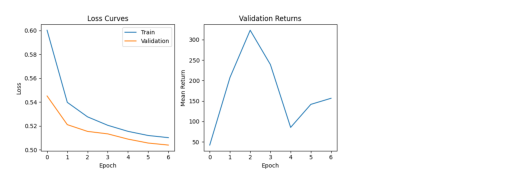

In [3]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_lstm_training.png")

Average reward over 5 episodes: 67.60

Результат ожидаемо хуже, чем в предыдущем экперименте, так как данных не хватает для такого RTG. Однако, лосс сошелся к тому же значению.

#### RGT = 200

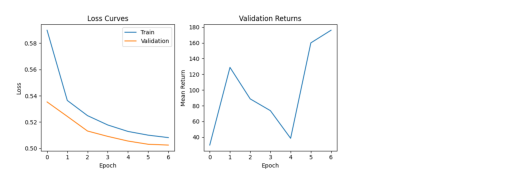

In [4]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_lstm_training.png")

Average reward over 5 episodes: 201.80

Средняя награда превзошла RTG. 

Вообще очень странно, что при смене RTG что-то меняется в обучении, потому что вот [здесь](https://github.com/Anya497/Decision-Transformer-with-Memory-for-POMDPs/blob/dt_with_memory/run_memory_dt.py#L110) RTG все равно задается 500 (перезаписывается параметр, переданный из CLI). Да и максимальная награда в cartpole 500. то есть при выставлении 700 не должно было ничего поменяться. Кажется, изменения происходят только из-за того, что обучение с подкреплением не стабильно. И на 7 эпохах при одинаковых гиперпараметрах все может сильно отличаться. 

## Задание 3

А что если вместо MLP в LSTM запихнуть KANы? Эксперимент будет проводиться с параметрами из первого экперимента. Поменяется только слой с памятью.

#### TKAN

Я нашла библиотеку, где используется KAN в LSTM, но, кажется, это немного не то, что я имела в виду. И вообще реализация кажется сомнительной, но я попробую.

Ссылка на проект: https://github.com/SamerMakni/timekan/blob/main/timekan/models/tkan_lstm.py

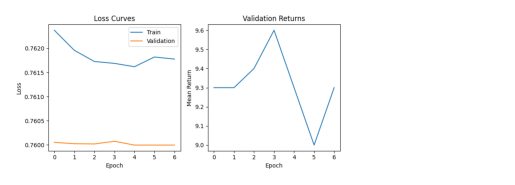

In [4]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_tkan_training.png")

Модель почти не обучилась. Лосс не снизился. Но и реализация lstm там сомнительная. Из того, что я поняла, там каждый раз создаются новые векторы контекстов, заполненные нулями. Реализую сама LSTM с KAN.

#### KANLSTM

Я реализовала LSTM с KAN, используя библиотеку pykan.

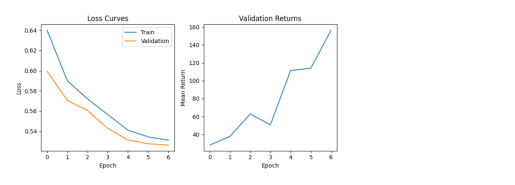

In [3]:
show_image("/home/chivi/ai_masters/RL/hw6/Decision-Transformer-with-Memory-for-POMDPs/models/memory_dt_velocity_cartpole_kanlstm_training.png")

Average reward over 5 episodes: 183.40

Средняя награда после 7 эпох обучения меньше, чем у предыдущих подходов. Скорее всего, KANы надо дольше учить.

Так же одна эпоха обучения такой модели занимает существенно больше времени, чем для обычного LSTM. Помимо этого моя неоптимиированная реализация требовала очень много памяти на вычисления, поэтому мне пришлось уменьшить длину контекста с 20 до 5.